In [81]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import i0, i1, k0, k1
import CoolProp.CoolProp as CP
from scipy.interpolate import interp1d
from tabulate import tabulate
import pandas as pd
from IPython.display import display # Importamos display para Jupyter

In [82]:
print(CP.get_global_param_string("incompressible_list_pure"))

HC20,PNF2,HY40,PMR,AS30,FoodProtein,HC40,TY20,TCO,ZS55,AS10,FoodAsh,PBB,HY20,T66,DEB,Hexane,FoodFiber,HY50,HC10,PMS2,PHR,XLT,DowQ,AS40,TD12,HC30,PNF,ZS25,HCB,TY10,HFE,HY30,HC50,AS20,DowQ2,PLR,DSF,DowJ2,ZS45,Water,S800,TX22,XLT2,HCM,FoodCarbohydrate,DowJ,PHE,LiqNa,NaK,TVP1,AS55,PGLT,FoodWater,PCL,ZS10,TY24,HY45,PMS1,PCR,TY15,Acetone,FoodFat,ZS40,TVP1869,Ethanol,SAB,Air,FoodIce,ExampleDigitalPure,T72,HFE2,NBS,ExamplePure


# Intercambiador de calor de un serpentín dentro de un tubo (sin aletas)

Ahora se plantea el siguiente intercambiador de calor:


Para calcular las temperaturas de salidas de ambos flujos, primero se calcula el calor máximo del intercambiador de calor:

$$
\dot{Q}_{max} = C_{min} \cdot (T_{in,agua} - T_{in,etanol})
$$

Calculando la efectividad $\varepsilon$ del intercambiador de calor de calor según:

$$
\varepsilon = \frac{1 - e^{-NTU(1-C_r)}}{1 - C_re^{-NTU(1-C_r)}}
$$

Se puede calcular el calor real transferido por el intercambiador de calor

$$
\dot{Q}_{Hx} = \varepsilon \dot{Q}_{max}
$$
 
Donde $NTU = \frac{UA}{C_{min}}$. El valor $UA$ se calcula de la siguiente forma:

$$
\frac{1}{UA} = \frac{1}{h_{agua}A_{agua}} + \frac{\ln(D_o/D_i)}{2\pi L k_{cobre}} + \frac{1}{h_{etanol}A_{etanol}}
$$

Donde $A_{agua}$ es el área del manto interior del tubo que contiene al agua, $A_{etanol}$ es el área del manto exterior del tubo que contiene al agua. El coeficiente de convección $h_{agua}$ se calcula a partir del número de Nusselt para un tubo helicoidal, mientras que $h_{etanol}$ se calcula a partir del número de Nusselt para el flujo por un tubo.

In [83]:
class IntercambiadorSerpentin:

    '''Clase para modelar un intercambiador de calor de contraflujo.
    Se asumirá que el fluido caliente va por el serpentín, y el frío por la sección anular'''

    def __init__(self, Q_hot, Q_cold, T_in_hot, T_in_cold, D_in_hot, D_out_hot, D_in_cold, D_out_cold, Length, k_tube, C_coil, S_coil):

        '''Recibe:
        Q_hot: Caudal volumétrico del fluido caliente (m^3/s)
        Q_cold: Caudal volumétrico del fluido frío (m^3/s)
        T_in_hot: Temperatura de entrada del fluido caliente (K)
        T_in_cold: Temperatura de entrada del fluido frío (K)
        D_in_hot: Diámetro interno del tubo del fluido caliente (m)
        D_out_hot: Diámetro externo del tubo del fluido caliente (m)
        D_in_cold: Diámetro interno del tubo del fluido frío (m)
        D_out_cold: Diámetro externo del tubo del fluido frío (m)
        Length: Longitud del intercambiador (m)
        k_tube: Conductividad térmica del material del tubo (W/m·K)
        C_coil: Diámetro del centro del serpentín (m)
        S_coil: Paso del serpentín (m)'''

        self.Q_hot = Q_hot
        self.Q_cold = Q_cold
        self.T_in_hot = T_in_hot
        self.T_in_cold = T_in_cold
        self.D_in_hot = D_in_hot
        self.D_out_hot = D_out_hot
        self.D_in_cold = D_in_cold
        self.D_out_cold = D_out_cold
        self.Length = Length
        self.k_tube = k_tube
        self.C_coil = C_coil
        self.S_coil = S_coil
        self.P = 101325  # Presión atmosférica en Pa
        self.cold_fluid = 'Water'
        self.roughness = 0.00015e-2 # Rugosidad del cobre en metros

    def calcular_propiedades(self):
        self.rho_hot = CP.PropsSI('D', 'T', self.T_in_hot, 'P', self.P, 'Water')
        self.cp_hot = CP.PropsSI('C', 'T', self.T_in_hot, 'P', self.P, 'Water')
        self.mu_hot = CP.PropsSI('V', 'T', self.T_in_hot, 'P', self.P, 'Water')
        self.k_hot = CP.PropsSI('L', 'T', self.T_in_hot, 'P', self.P, 'Water')  
        self.beta_hot = CP.PropsSI('ISOBARIC_EXPANSION_COEFFICIENT', 'T', self.T_in_hot, 'P', self.P, 'Water')
        self.nu_hot = self.mu_hot / self.rho_hot
        self.m_dot_hot = self.rho_hot * self.Q_hot
        self.Re_hot = (4 * self.m_dot_hot) / (np.pi * (self.D_in_hot) * self.mu_hot)
        self.Pr_hot = self.cp_hot * self.mu_hot / self.k_hot
        self.De_hot = self.Re_hot * np.sqrt(self.D_in_hot / self.C_coil) # Número de Dean para el serpentín
        self.velocity_hot = self.m_dot_hot / (self.rho_hot * (np.pi * (self.D_in_hot/2)**2))


        self.rho_cold = CP.PropsSI('D', 'T', self.T_in_cold, 'P', self.P, self.cold_fluid)
        self.cp_cold = CP.PropsSI('C', 'T', self.T_in_cold, 'P', self.P, self.cold_fluid)
        self.mu_cold = CP.PropsSI('V', 'T', self.T_in_cold, 'P', self.P, self.cold_fluid)
        self.k_cold = CP.PropsSI('L', 'T', self.T_in_cold, 'P', self.P, self.cold_fluid)
        self.beta_cold = CP.PropsSI('ISOBARIC_EXPANSION_COEFFICIENT', 'T', self.T_in_cold, 'P', self.P, self.cold_fluid)
        self.nu_cold = self.mu_cold / self.rho_cold
        self.m_dot_cold = self.rho_cold * self.Q_cold
        self.Re_cold = (4 * self.m_dot_cold) / (np.pi * (self.D_in_cold) * self.mu_cold)
        self.Pr_cold = self.cp_cold * self.mu_cold / self.k_cold
        self.D_h = self.D_in_cold - self.D_out_hot

        self.C_min = min(self.m_dot_hot * self.cp_hot, self.m_dot_cold * self.cp_cold)
        self.C_max = max(self.m_dot_hot * self.cp_hot, self.m_dot_cold * self.cp_cold)
        self.C_ratio = self.C_min / self.C_max

    def conveccion_serpentin(self):

        '''Calculamos el coeficiente de convección para el 
        fluido caliente, que va por el serpentín.'''

        self.A_hot = np.pi * self.D_in_hot * self.Length

        a = (1 + (957 / ((self.De_hot ** 2)) *self.Pr_hot)) ** 2
        b = 1 + (0.477 / self.Pr_hot)

        first_nusselt_term = (3.657 + (4.343/a))**3
        second_nusselt_term = 1.158 * (((self.De_hot) / b) ** (3/2))

        self.Nu_hot = (first_nusselt_term + second_nusselt_term) ** (1/3)
        self.h_hot = self.Nu_hot * self.k_hot / self.D_in_hot

    def conveccion_tubo(self):
        
        '''Calculamos el coeficiente de convección para el 
        fluido frío, que va por la sección anular.'''

        self.A_cold = np.pi * (self.D_out_hot * self.Length)

        if self.Re_cold < 2300:
            self.Nu_cold = 4.36
        else:
            self.Nu_cold = 0.023 * (self.Re_cold ** 0.8) * (self.Pr_cold ** 0.3)

        self.h_cold = self.Nu_cold * self.k_cold / self.D_h

    def calcular_UA(self):

        '''Calculamos el producto UA para cada fluido y el total.'''

        self.R_hot = 1 / (self.h_hot * self.A_hot)
        self.R_cold = 1 / (self.h_cold * self.A_cold)
        self.R_conduction = np.log(self.D_out_hot / self.D_in_hot) / (2 * np.pi * self.k_tube * self.Length)

        # Para intercambiadores en contraflujo, el UA total se calcula como:
        self.UA_total = 1 / (self.R_hot + self.R_cold + self.R_conduction)

    def calcular_efectividad(self):
        
        '''Calculamos la efectividad del intercambiador de calor.'''

        self.NTU = self.UA_total / self.C_min

        exp_term = np.exp(-self.NTU * (1 - self.C_ratio))

        if self.C_min == self.C_max:
            self.efectividad = self.NTU / (1 + self.NTU)
        else:
            self.efectividad = (1 - exp_term) / (1 - (self.C_ratio * exp_term))

    def calcular_temperaturas_salida(self):
        
        '''Calculamos las temperaturas de salida de ambos fluidos.'''

        self.Q_max = self.C_min * (self.T_in_hot - self.T_in_cold)
        self.Q_hx = self.efectividad * self.Q_max

        self.T_out_hot = self.T_in_hot - (self.Q_hx / (self.m_dot_hot * self.cp_hot))
        self.T_out_cold = self.T_in_cold + (self.Q_hx / (self.m_dot_cold * self.cp_cold))

    def calcular_numero_de_vueltas(self):
        '''
        Calculamos la altura y vueltas según nomenclatura Incropera:
        C: Diámetro externo del serpentín
        S: Paso (distancia entre centros de tubos adyacentes)
        '''
        # 1. Diámetro medio o de curvatura (desde el centro del tubo)
        diametro_medio = self.C_coil
        
        # 2. Longitud de una vuelta completa (considerando la inclinación por el paso)
        longitud_una_vuelta = np.sqrt((np.pi * diametro_medio)**2 + self.S_coil**2)
        
        # 3. Número de vueltas necesarias para cubrir la longitud total del tubo (Length)
        self.N_vueltas = self.Length / longitud_una_vuelta
        
        # 4. Altura total del serpentín (desde el centro del primer tubo al centro del último)
        # Nota: La altura física total sería (self.N_vueltas * self.S_coil) + self.D_out_hot
        self.altura_serpentin_total = self.N_vueltas * self.S_coil + self.D_out_hot

    def verificar_laminaridad(self):
        
        '''Verificamos si el flujo es laminar en el serpentín'''

        self.Re_crit = 2100 * (1 + 12*((self.C_coil / self.D_in_hot) ** (-0.5)))
        self.laminar_hot = self.Re_hot < self.Re_crit

    def verificar_rangos_correlacion(self):

        self.correlacion_hot_valida = (self.C_coil / self.D_in_hot) > 3 and 0.005 < self.Pr_hot < 1600

    def perdidas_tubo_recto(self):

        if self.Re_hot < 2300:
            # For laminar flow, use the formula f = 64 / Re
            self.f_straight = 64 / self.Re_hot
        else:
            # Calculate friction factor using Swamee-Jain equation
            self.f_straight = 0.25 / ( ( ( np.log10( ((self.roughness / self.D_in_hot) / 3.7) + (5.74 / (self.Re_hot ** 0.9))) ) ) ** 2)

    def perdidas_helice(self):

        # Calculamos las pérdidas de fricción debido a la geometría helicoidal

        if self.De_hot < 30:
            factor_curvatura = 1
        elif 30 <=self.De_hot < 300:
            factor_curvatura = 0.419 * (self.De_hot ** (0.275))
        else:
            factor_curvatura = 0.1125 * (self.De_hot ** (0.5))

        self.f_helice = self.f_straight * factor_curvatura

        self.altura_perdidas = (self.f_helice * self.Length / self.D_in_hot) * (self.velocity_hot ** 2) / (2 * 9.81)

    def chequear_geometria_serpentin(self):

        factor_diseño = 2
        self.cumple_restriccion_geometrica = self.C_coil > self.D_out_hot * factor_diseño
            
    def grafico_intercambiador(self):
        
        '''Generamos un gráfico del intercambiador de calor.'''

        plt.figure(figsize=(10, 6))
        plt.plot([0, self.Length], [self.T_in_hot - 273.15, self.T_out_hot - 273.15], label='Agua', marker='o')
        plt.plot([self.Length, 0], [self.T_in_cold - 273.15, self.T_out_cold - 273.15], label='Etanol', marker='o')
        plt.xlabel('Longitud del Intercambiador (m)')
        plt.ylabel('Temperatura (K)')
        plt.title('Perfil de Temperatura en el Intercambiador de Calor')
        plt.legend()
        plt.grid()
        plt.show()

    def resumen(self):

        '''Imprimimos un resumen de los resultados obtenidos.'''

        data = [
            ['T_in_hot (K)', self.T_in_hot - 273.15],
            ['T_out_hot (K)', self.T_out_hot - 273.15],
            ['T_in_cold (K)', self.T_in_cold - 273.15],
            ['T_out_cold (K)', self.T_out_cold - 273.15],
            ['Efectividad', self.efectividad],
            ['UA_total (W/K)', self.UA_total],
            ['Re_hot', self.Re_hot],
            ['Re_cold', self.Re_cold],
            ['h_hot (W/m^2K)', self.h_hot],
            ['h_cold (W/m^2K)', self.h_cold],
            ['Número de vueltas', self.N_vueltas],
            ['Altura total del serpentín (m)', self.altura_serpentin_total]
        ]
        headers = ['Parámetro', 'Valor']
        print(tabulate(data, headers=headers, tablefmt="grid"))

    def ejecutar(self):
        
        '''Ejecutamos todos los cálculos en orden.'''

        self.calcular_propiedades()
        self.conveccion_serpentin()
        self.conveccion_tubo()
        self.calcular_UA()
        self.calcular_efectividad()
        self.calcular_temperaturas_salida()
        self.calcular_numero_de_vueltas()
        self.verificar_laminaridad()
        self.verificar_rangos_correlacion()
        self.perdidas_tubo_recto()
        self.perdidas_helice()
        self.chequear_geometria_serpentin()
        # self.resumen()
        # self.grafico_intercambiador()


Ejemplo de uso:

In [84]:
Q_hot = 1 * 0.001 / 60 # (pasamos de L/min a m³/s)
Q_cold = 15 * 0.001 / 60 # (pasamos de L/min a m³/s)
T_in_hot = 20 + 273.15  # Temperatura de entrada del fluido caliente (K)
T_in_cold = 4 + 273.15  # Temperatura de entrada del fluido frío (K)
D_in_hot = (6.35 - (2*0.6)) / 1000  # Diámetro interno del tubo del fluido caliente (m)
D_out_hot = 6.35 / 1000  # Diámetro externo del tubo del fluido caliente (m)
D_in_cold = 8e-3  # Diámetro interno del tubo del fluido frío (m)
D_out_cold = 10e-3  # Diámetro externo del tubo del fluido frío (m)
Length = 0.95 # Longitud del intercambiador (m)
k_tube = 390  # Conductividad térmica del material del tubo (W/m·K)
C_coil = 7.2e-3  # Diámetro del centro del serpentín (m)
S_coil = 1.5*D_out_hot # Paso del serpentín (m)

intercambiador = IntercambiadorSerpentin(Q_hot, Q_cold, T_in_hot, T_in_cold, D_in_hot, D_out_hot, D_in_cold, D_out_cold, Length, k_tube, C_coil, S_coil)
intercambiador.ejecutar()


## Optimización de intercambiador sin aletas

In [85]:
# 0. Definición de parámetros fijos

Q_cold = 15 * 0.001 / 60 # (pasamos de L/min a m³/s)
T_in_hot = 20 + 273.15  # Temperatura de entrada del fluido caliente (K)
T_in_cold = 4 + 273.15  # Temperatura de entrada del fluido frío (K)
D_in_hot = (6.35 - (2*0.6)) / 1000  # Diámetro interno del tubo del fluido caliente (m)
D_out_hot = 6.35 / 1000  # Diámetro externo del tubo del fluido caliente (m)
Length = 0.95 # Longitud del intercambiador (m)
k_tube = 390  # Conductividad térmica del material del tubo (W/m·K)
S_coil = 1.5*D_out_hot # Paso del serpentín (m)
t_aleta = 1e-3 # Espesor de la aleta (m)

# 1. Definición de los espacios de búsqueda
possible_hot_flow_rates = np.array([0.7, 0.8, 0.9, 1]) * 0.001 / 60 # De 0.5 a 1 L/min, convertidos a m³/s

# Diámetros comerciales de PVC
# https://catalogo.extension.cchc.cl/documentos/documentos/16094.pdf
possible_cold_inner_diameters = np.array([8, 10, 13.6, 17, 22, 27.2, 34, 42.6, 53.6, 63.8, 76.6, 93.6, 106.4, 119.2]) * 1e-3
possible_cold_outer_diameters = np.array([10, 12, 16, 20, 25, 32, 40, 50, 63, 75, 90, 110, 125, 140]) * 1e-3

# Proporciones del serpentín respecto al tubo de PVC (del 10% al 90%)
proporciones_serpentin = np.linspace(0.1, 0.9, 9) 

results = []

# 2. Bucle anidado para explorar todas las combinaciones

for Q_hot in possible_hot_flow_rates:

    for D_cold_in, D_cold_out in zip(possible_cold_inner_diameters, possible_cold_outer_diameters):
        for proporcion in proporciones_serpentin:
            
            # Calculamos el diámetro del serpentín para esta proporción
            C_coil_dinamico = proporcion * D_cold_in
                
            # Instanciamos y ejecutamos el modelo
            intercambiador = IntercambiadorSerpentin(
                Q_hot, Q_cold, T_in_hot, T_in_cold, D_in_hot, D_out_hot, 
                D_cold_in, D_cold_out, Length, k_tube, C_coil_dinamico, S_coil
            )
            intercambiador.ejecutar()

            if (not intercambiador.laminar_hot) or (not intercambiador.correlacion_hot_valida) or not intercambiador.cumple_restriccion_geometrica:
                continue
            else:
                # Guardamos los resultados
                results.append({
                    'D_in_PVC (mm)': round(D_cold_in * 1000, 4),
                    'D_out_PVC (mm)': round(D_cold_out * 1000, 4),
                    'Q_agua (L/min)': round(intercambiador.Q_hot * 1000 * 60, 2),
                    'C_coil (mm)': round(C_coil_dinamico * 1000, 4),
                    'Delta T agua (°C)': round(intercambiador.T_in_hot - intercambiador.T_out_hot, 4),
                    'UA Total (W/K)': round(intercambiador.UA_total, 4),
                    'Efectividad': round(intercambiador.efectividad, 4),
                    'Altura Serpentín (m)': round(intercambiador.altura_serpentin_total, 4),
                    'Número de Vueltas': round(intercambiador.N_vueltas, 4),
                    'Altura Perdidas (m)': round(intercambiador.altura_perdidas, 4)
                })

# 3. Análisis con Pandas

# Forzar a Pandas a mostrar todas las columnas sin truncar
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Convertimos la lista de diccionarios en un DataFrame
df_resultados = pd.DataFrame(results)

# Encontramos el índice de la fila con la menor temperatura de salida
indice_optimo = df_resultados['Delta T agua (°C)'].idxmax()
configuracion_optima = df_resultados.loc[indice_optimo]

# 4. Mostrar resultados
print("--- RESUMEN DE OPTIMIZACIÓN ---")
print(f"Total de configuraciones simuladas: {len(df_resultados)}")

print("\nCONFIGURACIÓN ÓPTIMA ENCONTRADA:")
# Al ser una sola fila (Serie), la convertimos a DataFrame con .to_frame() para que se vea bonita, y la transponemos con .T
display(configuracion_optima.to_frame().T)

print("\nTOP 5 MEJORES DISEÑOS:")
top_5 = df_resultados.sort_values(by='Delta T agua (°C)', ascending=False).head(5)
# display() renderiza la tabla completa en Jupyter Notebook
display(top_5)

# Guardamos el DataFrame completo en un archivo CSV para análisis posterior
df_resultados.to_csv('datos_experimentales/resultados_intercambiador_sin_aletas.csv', index=False)

--- RESUMEN DE OPTIMIZACIÓN ---
Total de configuraciones simuladas: 248

CONFIGURACIÓN ÓPTIMA ENCONTRADA:


,D_in_PVC (mm),D_out_PVC (mm),Q_agua (L/min),C_coil (mm),Delta T agua (°C),UA Total (W/K),Efectividad,Altura Serpentín (m),Número de Vueltas,Altura Perdidas (m)
0,22.0,25.0,0.7,17.6,7.1175,29.0046,0.4448,0.1676,16.9321,0.5942



TOP 5 MEJORES DISEÑOS:


,D_in_PVC (mm),D_out_PVC (mm),Q_agua (L/min),C_coil (mm),Delta T agua (°C),UA Total (W/K),Efectividad,Altura Serpentín (m),Número de Vueltas,Altura Perdidas (m)
0,22.0,25.0,0.7,17.6,7.1175,29.0046,0.4448,0.1676,16.9321,0.5942
1,22.0,25.0,0.7,19.8,7.0559,28.6609,0.4410,0.1501,15.0965,0.5770
62,22.0,25.0,0.8,17.6,6.5671,29.7772,0.4104,0.1676,16.9321,0.7946
63,22.0,25.0,0.8,19.8,6.5106,29.4376,0.4069,0.1501,15.0965,0.7716
124,22.0,25.0,0.9,17.6,6.1002,30.4502,0.3813,0.1676,16.9321,1.0277


# Intercambiador de calor de un serpentín dentro de un tubo (con aletas)

Para el caso de las aletas, estan aumentan el área de contacto para la convección exterior, por lo que se modifica el valor de $UA$ (y por ende, la efectividad del intercambiador) según:

$$
\frac{1}{UA} = \frac{1}{h_{agua}A_{agua}} + \frac{\ln(D_o/D_i)}{2\pi L k_{cobre}} + \frac{1}{\eta_0 h_{etanol}A_{t}}
$$

Donde $A_t = NA_f + \pi D_{out,agua} (L - Nt)$ es el área total superficial ($A_f$ es el área de una aleta, t es el espesor de la aleta). En este caso se utilizan aletas anulares. La eficiencia global de todas las aletas se calcula según:

$$
\eta_0 = 1 - \frac{NA_f}{A_t}(1 - \eta_f)
$$

Donde $\eta_f$ es la eficiencia de una única aleta, la cual se puede calcular a partir de la siguiente expresión usando funciones de Bessel.

$$
\eta_f = C_2 \frac{K_1(mr_1) I_1(mr_{2c}) - I_1(mr_1)K_1(mr_{2c})}{I_0(mr_1)K_1(mr_{2c}) + K_0(mr_1)I_1(mr_{2c})}
$$

In [86]:
class IntercambiadorSerpentinAletas(IntercambiadorSerpentin):

    '''Clase para modelar un intercambiador de calor de contraflujo con aletas.
    Se asumirá que el fluido caliente va por el serpentín, y el frío por la sección anular'''

    def __init__(self, Q_hot, Q_cold, T_in_hot, T_in_cold, D_in_hot, D_out_hot, D_in_cold, D_out_cold, Length, k_tube, C_coil, S_coil, N_aletas, D_aleta, t_aleta):

        super().__init__(Q_hot, Q_cold, T_in_hot, T_in_cold, D_in_hot, D_out_hot, D_in_cold, D_out_cold, Length, k_tube, C_coil, S_coil)
        self.N_aletas = N_aletas
        self.D_aleta = D_aleta
        self.t_aleta = t_aleta

    def calcular_geometria_aleta(self):
        self.r2 = self.D_aleta / 2
        self.r1 = self.D_out_hot / 2
        self.r2c = self.r2 + (self.t_aleta / 2)

    def calcular_efectividad_aleta(self):

        '''Calculamos la efectividad de una aleta'''

        self.m = np.sqrt((2 * self.h_cold) / (self.k_tube * self.t_aleta))
        K1_mr1 = k1(self.m * self.r1)
        I1_mr2c = i1(self.m * self.r2c)
        I1_mr1 = i1(self.m * self.r1)
        K1_mr2c = k1(self.m * self.r2c)
        I0_mr1 = i0(self.m * self.r1)
        K1_mr2c = k1(self.m * self.r2c)
        K0_mr1 = k0(self.m * self.r1)
        I1_mr2c = i1(self.m * self.r2c)

        numerador = (K1_mr1 * I1_mr2c) - (I1_mr1 * K1_mr2c)
        denominador = (I0_mr1 * K1_mr2c) + (K0_mr1 * I1_mr2c)

        C2 = (2*self.r1 / self.m) / ((self.r2c**2 - self.r1**2))

        self.eficiencia_aleta = C2 * (numerador / denominador)

    def calcular_eficiencia_total(self):
        
        '''Calculamos la efectividad total del intercambiador con aletas.'''

        self.A_f = 2 * np.pi * (self.r2c**2 - self.r1**2)

        self.A_t = (self.N_aletas * self.A_f) + (2 * np.pi * self.r1 * (self.Length - self.N_aletas * self.t_aleta))

        self.eficiencia_total = 1 - (((self.A_f * self.N_aletas)/ (self.A_t)) * (1 - self.eficiencia_aleta))

    def calcular_UA(self):

        '''Calculamos el producto UA para cada fluido y el total.'''

        self.R_hot = 1 / (self.h_hot * self.A_hot)
        self.R_cold = 1 / (self.eficiencia_total * self.h_cold * self.A_t)
        self.R_conduction = np.log(self.D_out_hot / self.D_in_hot) / (2 * np.pi * self.k_tube * self.Length)

        # Para intercambiadores en contraflujo, el UA total se calcula como:
        self.UA_total = 1 / (self.R_hot + self.R_cold + self.R_conduction)

    def calcular_largo_sin_aletas(self):
        
        '''Calculamos el largo efectivo del intercambiador sin considerar las aletas.'''

        self.Length_sin_aletas = self.Length - (self.N_aletas * self.t_aleta)

    def chequear_rangos_correlacion_serpentin(self):
        condicion_1 = (1 <= self.Re_hot * np.sqrt(self.D_in_hot / self.C_coil)) and (1000 >= self.Re_hot * np.sqrt(self.D_in_hot / self.C_coil))
        condicion_2 = (0.005 <= self.Pr_hot <= 1600)

        if condicion_1 and condicion_2:
            print("Las condiciones para la correlación del serpentín se cumplen.")
        else:
            print("Las condiciones para la correlación del serpentín NO se cumplen. Re_hot * sqrt(D_in_hot / C_coil) =", self.Re_hot * np.sqrt(self.D_in_hot / self.C_coil), "y Pr_hot =", self.Pr_hot)

        

    def ejecutar(self):
        
        '''Ejecutamos todos los cálculos en orden.'''

        self.calcular_propiedades()
        self.conveccion_serpentin()
        self.conveccion_tubo()
        self.calcular_geometria_aleta()
        self.calcular_efectividad_aleta()
        self.calcular_eficiencia_total()
        self.calcular_UA()
        self.calcular_efectividad()
        self.calcular_temperaturas_salida()
        self.calcular_largo_sin_aletas()
        self.calcular_numero_de_vueltas()
        self.verificar_laminaridad()
        self.verificar_rangos_correlacion()
        self.perdidas_tubo_recto()
        self.perdidas_helice()
        # self.resumen()
        # self.grafico_intercambiador()  

Ahora armamos gráficos en función del número de aletas para ver cómo varían los resultados

In [87]:
Q_hot = 1 * 0.001 / 60 # (pasamos de L/min a m³/s)
Q_cold = 15 * 0.001 / 60 # (pasamos de L/min a m³/s)
T_in_hot = 20 + 273.15  # Temperatura de entrada del fluido caliente (K)
T_in_cold = 4 + 273.15  # Temperatura de entrada del fluido frío (K)
D_in_hot = (6.35 - (2*0.6)) / 1000  # Diámetro interno del tubo del fluido caliente (m)
D_out_hot = 6.35 / 1000  # Diámetro externo del tubo del fluido caliente (m)
D_in_cold = 8e-3  # Diámetro interno del tubo del fluido frío (m)
D_out_cold = 10e-3  # Diámetro externo del tubo del fluido frío (m)
Length = 0.95 # Longitud del intercambiador (m)
k_tube = 390  # Conductividad térmica del material del tubo (W/m·K)
C_coil = 7.2e-3  # Diámetro del centro del serpentín (m)
S_coil = 1.5*D_out_hot # Paso del serpentín (m)
D_aleta = 6.985e-3 # Diámetro de la aleta (m)
t_aleta = 1e-3 # Espesor de la aleta (m)
N_aletas = 10 # Número de aletas
intercambiador_aletas = IntercambiadorSerpentinAletas(Q_hot, Q_cold, T_in_hot, T_in_cold, D_in_hot, D_out_hot, D_in_cold, D_out_cold, Length, k_tube, C_coil, S_coil, N_aletas, D_aleta, t_aleta)
intercambiador_aletas.ejecutar()
intercambiador_aletas.chequear_rangos_correlacion_serpentin()

Las condiciones para la correlación del serpentín NO se cumplen. Re_hot * sqrt(D_in_hot / C_coil) = 3473.098004828751 y Pr_hot = 7.007763685675426


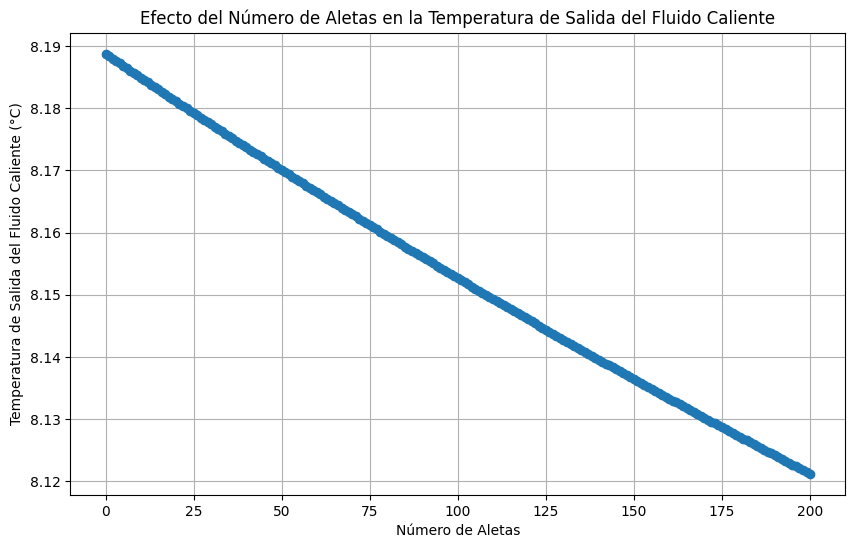

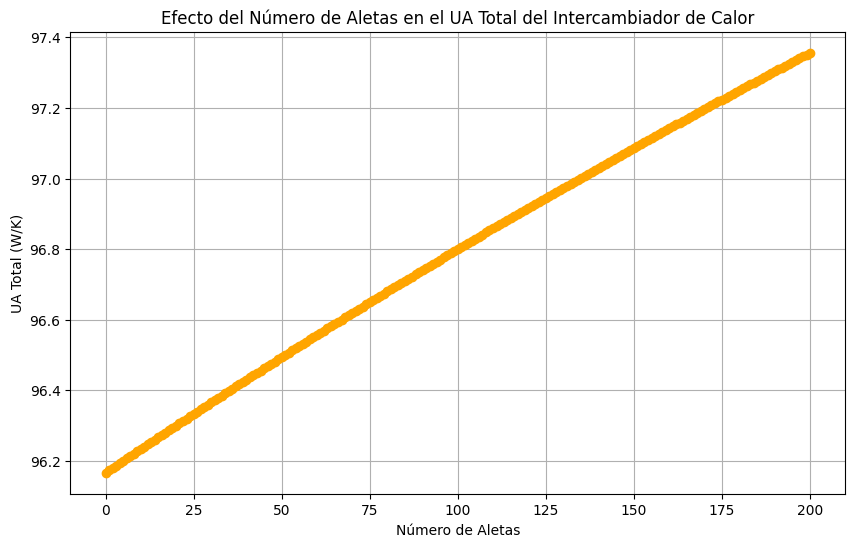

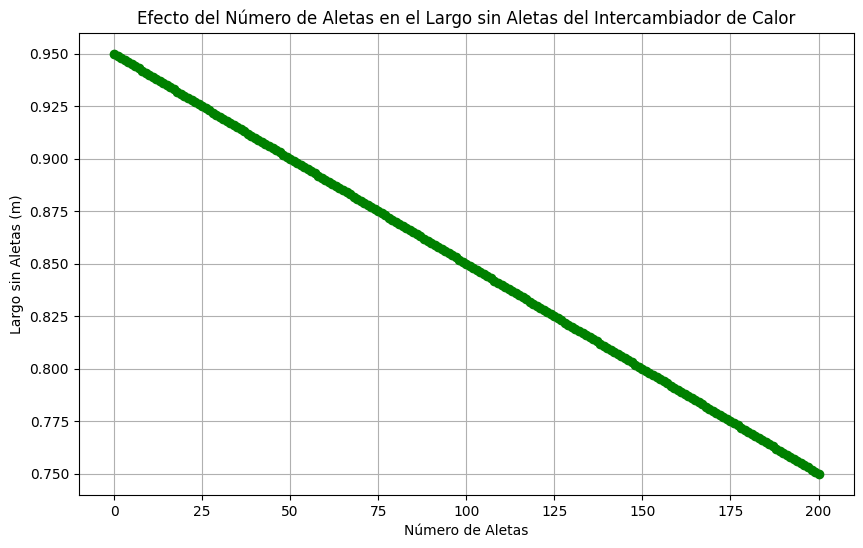

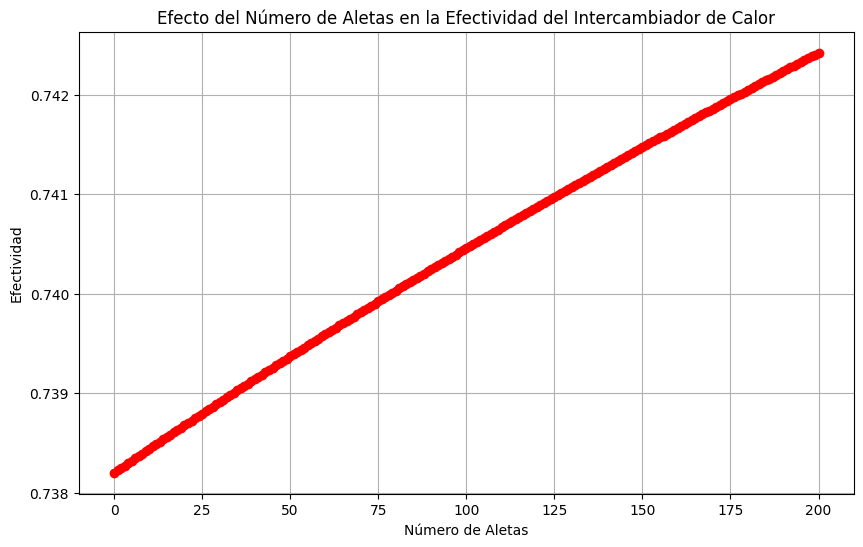

In [88]:
numero_aletas = np.arange(0, 201, 1)  # De 0 a 200 aletas
temperaturas_salida_hot = []
valores_UA = []
largo_sin_aletas = []
efectividades = []
for N_aletas in numero_aletas:
    intercambiador_aletas = IntercambiadorSerpentinAletas(Q_hot, Q_cold, T_in_hot, T_in_cold, D_in_hot, D_out_hot, D_in_cold, D_out_cold, Length, k_tube, C_coil, S_coil, N_aletas, D_aleta, t_aleta)
    intercambiador_aletas.ejecutar()
    temperaturas_salida_hot.append(intercambiador_aletas.T_out_hot - 273.15)
    largo_sin_aletas.append(intercambiador_aletas.Length_sin_aletas)
    valores_UA.append(intercambiador_aletas.UA_total)
    efectividades.append(intercambiador_aletas.efectividad)

# Gráfico de temperatura de salida del fluido caliente vs número de aletas
plt.figure(figsize=(10, 6))
plt.plot(numero_aletas, temperaturas_salida_hot, marker='o')
plt.xlabel('Número de Aletas')
plt.ylabel('Temperatura de Salida del Fluido Caliente (°C)')
plt.title('Efecto del Número de Aletas en la Temperatura de Salida del Fluido Caliente')
plt.grid()
plt.show()

# Gráfico de UA total vs número de aletas
plt.figure(figsize=(10, 6))
plt.plot(numero_aletas, valores_UA, marker='o', color='orange')
plt.xlabel('Número de Aletas')
plt.ylabel('UA Total (W/K)')
plt.title('Efecto del Número de Aletas en el UA Total del Intercambiador de Calor')
plt.grid()
plt.show()

# Gráfico del largo sin aletas vs número de aletas
plt.figure(figsize=(10, 6))
plt.plot(numero_aletas, largo_sin_aletas, marker='o', color='green')
plt.xlabel('Número de Aletas')
plt.ylabel('Largo sin Aletas (m)')
plt.title('Efecto del Número de Aletas en el Largo sin Aletas del Intercambiador de Calor')
plt.grid()
plt.show()

# Gráfico de efectividad vs número de aletas
plt.figure(figsize=(10, 6))
plt.plot(numero_aletas, efectividades, marker='o', color='red')
plt.xlabel('Número de Aletas')
plt.ylabel('Efectividad')
plt.title('Efecto del Número de Aletas en la Efectividad del Intercambiador de Calor')
plt.grid()
plt.show()

## Optimización de parámetros para minimizar la temperatura de salida del fluido caliente

In [89]:
def chequear_geometria_serpentin_aletas(C_coil, D_out_hot, D_aleta, N):

    factor_diseño = 1.1

    if N > 0:
        return C_coil > (D_out_hot + D_aleta)
    else:
        return C_coil > D_out_hot * factor_diseño

In [90]:
# # 0. Definición de parámetros fijos

# Q_hot = 1 * 0.001 / 60 # (pasamos de L/min a m³/s)
# Q_cold = 15 * 0.001 / 60 # (pasamos de L/min a m³/s)
# T_in_hot = 20 + 273.15  # Temperatura de entrada del fluido caliente (K)
# T_in_cold = 4 + 273.15  # Temperatura de entrada del fluido frío (K)
# D_in_hot = (6.35 - (2*0.6)) / 1000  # Diámetro interno del tubo del fluido caliente (m)
# D_out_hot = 6.35 / 1000  # Diámetro externo del tubo del fluido caliente (m)
# Length = 0.95 # Longitud del intercambiador (m)
# k_tube = 25  # Conductividad térmica del material del tubo (W/m·K)
# S_coil = 1.5*D_out_hot # Paso del serpentín (m)
# t_aleta = 1e-3 # Espesor de la aleta (m)

# # 1. Definición de los espacios de búsqueda
# possible_fin_values = np.arange(0, 51, 1)  # De 0 a 50 aletas

# # Diámetros comerciales de PVC
# # https://catalogo.extension.cchc.cl/documentos/documentos/16094.pdf
# possible_cold_inner_diameters = np.array([8, 10, 13.6, 17, 22, 27.2, 34, 42.6, 53.6, 63.8, 76.6, 93.6, 106.4, 119.2]) * 1e-3
# possible_cold_outer_diameters = np.array([10, 12, 16, 20, 25, 32, 40, 50, 63, 75, 90, 110, 125, 140]) * 1e-3


# # Proporciones del serpentín respecto al tubo de PVC (del 10% al 90%)
# proporciones_serpentin = np.linspace(0.1, 0.9, 9) 

# # Definición de los posibles diámetros de la aleta
# possible_fin_diameters = np.linspace(1.1, 1.9, 9) * D_out_hot # Diámetros de aleta basados en el diámetro externo del tubo caliente

# results = []

# # 2. Bucle anidado para explorar todas las combinaciones
# for N in possible_fin_values:

#     for D_cold_in, D_cold_out in zip(possible_cold_inner_diameters, possible_cold_outer_diameters):
#         for proporcion in proporciones_serpentin:
#             for D_aleta in possible_fin_diameters:
            
#                 # Calculamos el diámetro del serpentín para esta proporción
#                 C_coil_dinamico = proporcion * D_cold_in
                    
#                 # Instanciamos y ejecutamos el modelo
#                 intercambiador = IntercambiadorSerpentinAletas(
#                     Q_hot, Q_cold, T_in_hot, T_in_cold, D_in_hot, D_out_hot, 
#                     D_cold_in, D_cold_out, Length, k_tube, C_coil_dinamico, S_coil, N, D_aleta, t_aleta
#                 )
#                 intercambiador.ejecutar()
                
#                 # Vefificamos que se cumplan las restricciones geométricas para el serpentín con aletas y que el flujo sea laminar si no se cumplen
#                 restriccion_geometrica_cumplida = chequear_geometria_serpentin_aletas(C_coil_dinamico, D_out_hot, D_aleta, N)
#                 if not (restriccion_geometrica_cumplida) or (not intercambiador.laminar_hot) or (not intercambiador.correlacion_hot_valida):
#                     continue
#                 else:
#                     # Guardamos los resultados
#                     results.append({
#                         'Aletas': N,
#                         'D_in_PVC (mm)': round(D_cold_in * 1000, 4),
#                         'D_out_PVC (mm)': round(D_cold_out * 1000, 4),
#                         'D_aleta (mm)': round(D_aleta * 1000, 4),
#                         'Proporción Serpentín': round(proporcion, 2),
#                         'C_coil (mm)': round(C_coil_dinamico * 1000, 4),
#                         'T_out_hot (°C)': round(intercambiador.T_out_hot - 273.15, 4),
#                         'UA Total (W/K)': round(intercambiador.UA_total, 4),
#                         'Efectividad': round(intercambiador.efectividad, 4),
#                         'Altura Serpentín (m)': round(intercambiador.altura_serpentin_total, 4),
#                         'Número de Vueltas': round(intercambiador.N_vueltas, 4),
#                         'Condicion Laminar en Serpentín': intercambiador.laminar_hot
#                     })

# # 3. Análisis con Pandas

# # Forzar a Pandas a mostrar todas las columnas sin truncar
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', 1000)

# # Convertimos la lista de diccionarios en un DataFrame
# df_resultados = pd.DataFrame(results)

# # Encontramos el índice de la fila con la menor temperatura de salida
# indice_optimo = df_resultados['T_out_hot (°C)'].idxmin()
# configuracion_optima = df_resultados.loc[indice_optimo]

# # 4. Mostrar resultados
# print("--- RESUMEN DE OPTIMIZACIÓN ---")
# print(f"Total de configuraciones simuladas: {len(df_resultados)}")

# print("\nCONFIGURACIÓN ÓPTIMA ENCONTRADA:")
# # Al ser una sola fila (Serie), la convertimos a DataFrame con .to_frame() para que se vea bonita, y la transponemos con .T
# display(configuracion_optima.to_frame().T)

# print("\nTOP 5 MEJORES DISEÑOS:")
# top_5 = df_resultados.sort_values(by='T_out_hot (°C)').head(5)
# # display() renderiza la tabla completa en Jupyter Notebook
# display(top_5)

# # Guardamos el DataFrame completo en un archivo CSV para análisis posterior
# df_resultados.to_csv('datos_experimentales/resultados_intercambiador_aletas.csv', index=False)